# 05b - So sanh Tracking (2 phan): Person-tracking (YOLOv8) va Face-tracking (YOLOv8+SCRFD cascade)

**Phan 1 - Person tracking:** co dinh detector YOLOv8s, chi doi 6 thuat toan tracking
(ByteTrack/BoT-SORT/OC-SORT/Deep OC-SORT/FastTracker/TrackTrack), danh gia tren MOT17
(ground truth NGUOI that, khong xap xi).

**Phan 2 - Face tracking qua cascade dung kien truc that:** YOLOv8 tim NGUOI trong ca
khung hinh -> cat crop TUNG nguoi -> SCRFD tim MAT trong TUNG crop -> quy doi toa do
mat ve theo khung hinh goc (cong lai offset crop) -> GOM het mat cua CA khung hinh
-> goi `tracker.update()` DUNG 1 LAN cho khung hinh do. Day chinh la kien truc that
cua `pipeline_runner.py`, khac voi lan truoc (SCRFD chay thang tren ca khung hinh rong
- da cho ket qua vo nghia vi mat qua nho, chi detect duoc 0.2% ground truth).

**Ground truth cho Phan 2 la XAP XI** (uoc luong tu box nguoi, vi MOT17 khong co nhan
mat that) - chi dung de so sanh TUONG DOI giua 6 tracker, khong so sanh tuyet doi voi
Phan 1.

In [ ]:
# ===== CELL 1: Thiet lap duong dan =====
import os
import time
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = r'D:\Code\Face recognition security system'
AI_DIR = os.path.join(BASE_DIR, 'ai')
BENCHMARK_DIR = os.path.join(AI_DIR, 'dataset', 'benchmarks')
RESULTS_DIR = os.path.join(AI_DIR, 'models', 'tracker_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

MOT_SEQUENCE = 'MOT17-02-FRCNN'
mot_seq_dir = os.path.join(BENCHMARK_DIR, MOT_SEQUENCE)
img_dir = os.path.join(mot_seq_dir, 'img1')
gt_path = os.path.join(mot_seq_dir, 'gt', 'gt.txt')

assert os.path.exists(img_dir) and os.path.exists(gt_path), (
    f"Chua thay du lieu MOT17 tai {mot_seq_dir}"
)
print("Da tim thay du lieu MOT17 tai:", mot_seq_dir)


Da tim thay du lieu MOT17 tai: D:\face-security-system\ai\dataset\benchmarks\MOT17-02-FRCNN


In [2]:
# ===== CELL 2: Cai dat / nang cap thu vien + kiem tra GPU =====
import numpy as np
import torch
import onnxruntime as ort

# Va np.asfarray - bi NumPy 2.0 xoa, nhung motmetrics van con goi ham nay
if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float: np.asarray(a, dtype=dtype)

import ultralytics
print(f"ultralytics version: {ultralytics.__version__}")

# 1. Kiem tra PyTorch (Dung cho YOLOv8)
CUDA_OK = torch.cuda.is_available()
TRACK_DEVICE = 0 if CUDA_OK else 'cpu'  # 0 = GPU dau tien

print(f"\nTorch version: {torch.__version__}")
print(f"CUDA available (PyTorch): {CUDA_OK}")
if CUDA_OK:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"\n=> YOLOv8 se chay tren device={TRACK_DEVICE} (GPU)")
else:
    print("KHONG thay GPU - YOLOv8 se tu dong roi ve CPU.")

# 2. Kiem tra ONNX Runtime (Dung cho InsightFace/SCRFD)
ort_providers = ort.get_available_providers()
print(f"\nONNX Runtime available providers: {ort_providers}")

if 'CUDAExecutionProvider' not in ort_providers:
    print("\n" + "="*60)
    print("[WARNING] CUDAExecutionProvider KHONG co san trong onnxruntime!")
    print("InsightFace (SCRFD) se bi FALLBACK ve CPU.")
    print("=> Vui long tai cuDNN 9.x (phu hop CUDA 12.x) va them duong dan")
    print("   chua file cudnn*.dll vao bien moi truong PATH cua Windows.")
    print("="*60)
else:
    print("\n[OK] ONNX Runtime co ho tro CUDA. InsightFace se chay tren GPU.")

ultralytics version: 8.4.104

Torch version: 2.11.0+cu128
CUDA available (PyTorch): True
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.8 GB

=> YOLOv8 se chay tren device=0 (GPU)

ONNX Runtime available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

[OK] ONNX Runtime co ho tro CUDA. InsightFace se chay tren GPU.


## Buoc 1 - Dung anh MOT17 thanh video tam + doc ground truth NGUOI

In [3]:
# ===== CELL 3: Dung sequence anh thanh 1 video tam =====

def build_video_from_image_sequence(image_dir, output_video_path, fps=25):
    frame_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.png')))
    assert frame_files, f"Khong tim thay anh nao trong {image_dir}"

    first_img = cv2.imread(os.path.join(image_dir, frame_files[0]))
    h, w = first_img.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))
    for fname in frame_files:
        writer.write(cv2.imread(os.path.join(image_dir, fname)))
    writer.release()
    return len(frame_files), w, h


temp_video_path = os.path.join(RESULTS_DIR, f'{MOT_SEQUENCE}_temp2_trackingcmp.mp4')
n_frames, seq_w, seq_h = build_video_from_image_sequence(img_dir, temp_video_path, fps=25)
print(f"Da dung {n_frames} anh ({seq_w}x{seq_h}) thanh video tam: {temp_video_path}")


Da dung 600 anh (1920x1080) thanh video tam: D:\face-security-system\ai\models\tracker_results\MOT17-02-FRCNN_temp2_trackingcmp.mp4


In [4]:
# ===== CELL 4: Doc ground truth NGUOI (chi giu pedestrian, conf==1) =====

gt_cols = ['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'cls', 'vis']
gt_df = pd.read_csv(gt_path, header=None, names=gt_cols)
gt_df = gt_df[(gt_df['conf'] == 1) & (gt_df['cls'] == 1)]

print(f"Ground truth NGUOI (sau loc): {len(gt_df)} box qua {gt_df['frame'].nunique()} frame")


Ground truth NGUOI (sau loc): 18581 box qua 600 frame


## Buoc 2 - Ham dung chung: tinh IoU + nap tracker theo ten

In [5]:
# ===== CELL 5: Ham IoU + ham nap tracker (dung chung cho ca 2 Phan) =====
from ultralytics.utils import YAML, IterableSimpleNamespace
from ultralytics.utils.checks import check_yaml

try:
    from ultralytics.trackers import TRACKER_MAP
except ImportError:
    from ultralytics.trackers.track import TRACKER_MAP

TRACKER_CONFIGS = {
    'ByteTrack':     'bytetrack.yaml',
    'BoT-SORT':      'botsort.yaml',
    'OC-SORT':       'ocsort.yaml',
    'Deep OC-SORT':  'deepocsort.yaml',
    'FastTracker':   'fasttrack.yaml',
    'TrackTrack':    'tracktrack.yaml',
}


def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xa1, ya1, xa2, ya2 = x1, y1, x1 + w1, y1 + h1
    xb1, yb1, xb2, yb2 = x2, y2, x2 + w2, y2 + h2

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_w, inter_h = max(0, inter_x2 - inter_x1), max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    union_area = w1 * h1 + w2 * h2 - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def create_tracker(tracker_config, device):
    """Nap tracker theo ten config - dung TRACKER_MAP noi bo cua ultralytics.
    LUU Y: ban ultralytics moi KHONG con nhan tham so frame_rate nua, chi truyen
    args theo VI TRI (khong dung keyword) de tranh lech ten tham so giua cac ban."""
    tracker_yaml_path = check_yaml(tracker_config)
    cfg = IterableSimpleNamespace(**YAML.load(tracker_yaml_path))
    cfg.device = device

    if cfg.tracker_type not in TRACKER_MAP:
        raise ValueError(f"Tracker '{cfg.tracker_type}' khong co trong TRACKER_MAP: {sorted(TRACKER_MAP)}")

    tracker_cls = TRACKER_MAP[cfg.tracker_type]
    return tracker_cls(cfg)  # truyen theo VI TRI, khong dung keyword 'args'/'frame_rate'


print("Da dinh nghia iou_xywh() va create_tracker()")


Da dinh nghia iou_xywh() va create_tracker()


## PHAN 1 - Person Tracking (YOLOv8 co dinh, doi 6 tracker)

Danh gia tren ground truth NGUOI THAT cua MOT17 - khong xap xi, dang tin 100%.

In [6]:
# ===== CELL 6: Ham chay person-tracking (YOLOv8 + tracker) =====
from ultralytics import YOLO

PERSON_CLASS_ID = 0
DETECTOR_MODEL = 'yolov8s.pt'


def run_person_tracker(tracker_config, video_path, conf=0.15, model_name=DETECTOR_MODEL):
    """Dung model.track() co san cua ultralytics - YOLOv8 la model CUA CHINH
    ultralytics nen khong can tu ghep tay nhu SCRFD o Phan 2."""
    model = YOLO(model_name)

    # --- Lam nong GPU truoc khi do FPS - tranh tinh nham chi phi khoi tao 1 lan
    #     vao rieng tracker chay dau tien (ByteTrack) ---
    if CUDA_OK:
        dummy = np.zeros((640, 640, 3), dtype=np.uint8)
        for _ in range(3):
            model.predict(dummy, device=TRACK_DEVICE, verbose=False)  # doi ten bien cho dung ham
        torch.cuda.synchronize()
        
    rows = []
    frame_count = 0

    start_time = time.time()
    results_gen = model.track(
        source=video_path, persist=True, tracker=tracker_config,
        classes=[PERSON_CLASS_ID], conf=conf, device=TRACK_DEVICE,
        stream=True, verbose=False,
    )

    for frame_idx, r in enumerate(results_gen, start=1):
        frame_count += 1
        boxes = r.boxes
        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy()
            track_ids = boxes.id.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), tid in zip(xyxy, track_ids):
                rows.append([frame_idx, int(tid), x1, y1, x2 - x1, y2 - y1])

    if CUDA_OK:
        torch.cuda.synchronize()
    elapsed = time.time() - start_time
    fps = frame_count / elapsed if elapsed > 0 else 0.0

    track_df = pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])
    return track_df, fps, elapsed


print(f"Da dinh nghia run_person_tracker() - detector co dinh: {DETECTOR_MODEL}")


Da dinh nghia run_person_tracker() - detector co dinh: yolov8s.pt


In [7]:
# ===== CELL 7: Chay Phan 1 - 6 tracker tren NGUOI, tinh MOTA/IDF1/FPS =====
import traceback
import motmetrics as mm


def evaluate_tracking(track_df, gt_this_df, tracker_name, fps, elapsed):
    acc = mm.MOTAccumulator(auto_id=False)
    all_frames = sorted(set(gt_this_df['frame'].unique().tolist()) | set(track_df['frame'].unique().tolist()))

    for frame in all_frames:
        gt_frame = gt_this_df[gt_this_df['frame'] == frame]
        tr_frame = track_df[track_df['frame'] == frame]

        gt_ids = gt_frame['id'].tolist()
        tr_ids = tr_frame['id'].tolist()
        gt_boxes = gt_frame[['x', 'y', 'w', 'h']].values
        tr_boxes = tr_frame[['x', 'y', 'w', 'h']].values

        dists = mm.distances.iou_matrix(gt_boxes, tr_boxes, max_iou=0.5)
        acc.update(gt_ids, tr_ids, dists, frameid=frame)

    mh = mm.metrics.create()
    summary = mh.compute(
        acc,
        metrics=['num_frames', 'mota', 'motp', 'idf1', 'num_switches',
                 'num_false_positives', 'num_misses', 'num_matches'],
        name=tracker_name,
    )
    row = summary.iloc[0].to_dict()
    row['tracker'] = tracker_name
    row['fps'] = round(fps, 2)
    row['elapsed_sec'] = round(elapsed, 1)
    return row, summary, mh


comparison_rows_person = []

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== [Phan 1 - Person] Dang chay {tracker_name} ===")
    try:
        track_df, fps, elapsed = run_person_tracker(tracker_config, temp_video_path, conf=0.15)
    except Exception:
        print(f"BO QUA {tracker_name}:")
        traceback.print_exc()
        continue

    print(f"Thu thap {len(track_df)} detection, {elapsed:.1f}s ({fps:.1f} FPS)")
    row, summary, mh = evaluate_tracking(track_df, gt_df, tracker_name, fps, elapsed)
    comparison_rows_person.append(row)
    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

comparison_df_person = pd.DataFrame(comparison_rows_person).set_index('tracker') if comparison_rows_person else None
if comparison_df_person is not None:
    comparison_df_person.to_csv(os.path.join(RESULTS_DIR, 'tracking_comparison_person.csv'))
    print("\n=== BANG TONG HOP PHAN 1 (Person tracking) ===")
comparison_df_person



=== [Phan 1 - Person] Dang chay ByteTrack ===
Thu thap 6523 detection, 7.5s (80.0 FPS)
          num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
ByteTrack        600 23.5% 0.211 34.0%  79 1035 13093        5409

=== [Phan 1 - Person] Dang chay BoT-SORT ===
Thu thap 6566 detection, 18.6s (32.2 FPS)
         num_frames  MOTA  MOTP  IDF1 IDs   FP    FN num_matches
BoT-SORT        600 24.0% 0.196 35.6%  63 1023 13038        5480

=== [Phan 1 - Person] Dang chay OC-SORT ===
Thu thap 6207 detection, 7.6s (79.5 FPS)
        num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
OC-SORT        600 23.1% 0.203 34.6%  83 918 13292        5206

=== [Phan 1 - Person] Dang chay Deep OC-SORT ===
Thu thap 5846 detection, 7.8s (77.3 FPS)
             num_frames  MOTA  MOTP  IDF1 IDs  FP    FN num_matches
Deep OC-SORT        600 22.5% 0.198 33.2%  71 797 13532        4978

=== [Phan 1 - Person] Dang chay FastTracker ===
Thu thap 6844 detection, 7.5s (80.4 FPS)
            num_frames  MOTA  MOT

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches,fps,elapsed_sec
tracker,,,,,,,,,,
ByteTrack,600.0,0.235402,0.211199,0.340344,79.0,1035.0,13093.0,5409.0,80.04,7.5
BoT-SORT,600.0,0.239869,0.195890,0.355987,63.0,1023.0,13038.0,5480.0,32.17,18.6
OC-SORT,600.0,0.230773,0.203441,0.345570,83.0,918.0,13292.0,5206.0,79.45,7.6
Deep OC-SORT,600.0,0.225015,0.197751,0.331518,71.0,797.0,13532.0,4978.0,77.32,7.8
FastTracker,600.0,0.235079,0.210441,0.338250,84.0,1196.0,12933.0,5564.0,80.40,7.5
TrackTrack,600.0,0.175179,0.142120,0.262788,12.0,161.0,15153.0,3416.0,32.51,18.5


## PHAN 2 - Face Tracking qua cascade YOLOv8 (nguoi) + SCRFD (mat tren crop)

Dung kien truc CASCADE THAT: YOLOv8 tim nguoi -> cat crop -> SCRFD tim mat TRONG
crop -> quy doi toa do ve khung hinh goc -> gom het mat CA khung hinh -> goi
`tracker.update()` DUNG 1 LAN moi khung hinh.

In [8]:
# ===== CELL 8: Khoi tao SCRFD (insightface) =====
from insightface.app import FaceAnalysis

FACE_DET_THRESH = 0.3

# Chi truyen CUDAExecutionProvider neu onnxruntime thuc su ho tro
if 'CUDAExecutionProvider' in ort.get_available_providers():
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    ctx_id = 0
else:
    providers = ['CPUExecutionProvider']
    ctx_id = -1
    print("[WARNING] Khong tim thay CUDA trong ONNX Runtime, InsightFace chay CPU.")

face_app = FaceAnalysis(name='buffalo_l', providers=providers)
face_app.prepare(ctx_id=ctx_id, det_size=(640, 640), det_thresh=FACE_DET_THRESH)

print(f"\nDa khoi tao SCRFD (buffalo_l)")
print(f"Providers duoc yeu cau: {providers}")

# Kiem tra thuc te model dang chay provider nao
try:
    actual_providers = face_app.det_model.session.get_providers()
    print(f"Providers thuc te dang chay: {actual_providers}")
    if 'CUDAExecutionProvider' not in actual_providers:
        print("\n[ERROR] InsightFace VAN DANG CHAY TREN CPU! Hay kiem tra lai cuDNN trong PATH.")
except Exception:
    pass

d:\face-security-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Admin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'

In [9]:
# ===== CELL 9: Uoc luong ground truth VUNG MAT tu ground truth NGUOI (XAP XI) =====
# CANH BAO: MOT17 khong co nhan mat that - day chi la xap xi de co con so so sanh
# TUONG DOI giua 6 tracker, KHONG dung de so sanh tuyet doi voi Phan 1.

FACE_HEIGHT_RATIO = 0.20
FACE_WIDTH_RATIO = 0.45


def estimate_face_gt(person_gt_df):
    face_rows = []
    for _, row in person_gt_df.iterrows():
        face_w = row['w'] * FACE_WIDTH_RATIO
        face_h = row['h'] * FACE_HEIGHT_RATIO
        face_x = row['x'] + (row['w'] - face_w) / 2
        face_y = row['y']
        face_rows.append([row['frame'], row['id'], face_x, face_y, face_w, face_h])
    return pd.DataFrame(face_rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])


gt_face_df = estimate_face_gt(gt_df)
print(f"Da uoc luong {len(gt_face_df)} vung mat (XAP XI, khong phai nhan that)")


Da uoc luong 18581 vung mat (XAP XI, khong phai nhan that)


In [10]:
# ===== CELL 10: Ham cascade YOLOv8 (nguoi) + SCRFD (mat tren crop) + tracker =====
from ultralytics.engine.results import Boxes

PERSON_CONF_FOR_CROP = 0.4


def run_face_tracker_via_crop(tracker_config, video_path, yolo_model_name=DETECTOR_MODEL):
    """Dung DUNG kien truc cascade that (giong pipeline_runner.py):
    1) YOLOv8 tim TAT CA nguoi trong CA khung hinh (chi detect, khong can track o day)
    2) Voi TUNG nguoi: cat crop -> SCRFD tim mat TRONG crop do
    3) Quy doi toa do mat tu he crop VE he khung hinh goc (cong lai offset x1,y1 cua crop)
    4) GOM het mat cua CA khung hinh thanh 1 danh sach
    5) CHI SAU KHI gom du, goi tracker.update() DUNG 1 LAN cho khung hinh do
       (khong goi rieng cho tung nguoi/tung crop - se lam sai bo dem frame ben trong tracker)
    """
    person_model = YOLO(yolo_model_name)
    # --- Lam nong GPU truoc khi do FPS - tranh tinh nham chi phi khoi tao 1 lan
    #     vao rieng tracker chay dau tien (ByteTrack) ---
    if CUDA_OK:
        dummy = np.zeros((640, 640, 3), dtype=np.uint8)
        for _ in range(3):
            person_model.predict(dummy, device=TRACK_DEVICE, verbose=False)  # doi ten bien cho dung ham
            face_app.get(dummy)
        torch.cuda.synchronize()
    tracker = create_tracker(tracker_config, device=TRACK_DEVICE)

    cap = cv2.VideoCapture(video_path)
    rows = []
    frame_count = 0

    start_time = time.time()
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        h, w = frame.shape[:2]

        # --- Buoc 1: YOLOv8 tim NGUOI trong CA khung hinh ---
        person_results = person_model.predict(
            frame, classes=[PERSON_CLASS_ID], conf=PERSON_CONF_FOR_CROP,
            device=TRACK_DEVICE, verbose=False,
        )[0]

        # --- Buoc 2+3: tung nguoi -> crop -> SCRFD -> quy doi toa do ve khung hinh goc ---
        frame_face_dets = []  # GOM het mat cua CA khung hinh nay (Buoc 4)
        if person_results.boxes is not None:
            person_boxes = person_results.boxes.xyxy.cpu().numpy()
            for px1, py1, px2, py2 in person_boxes:
                px1, py1 = max(0, int(px1)), max(0, int(py1))
                px2, py2 = min(w, int(px2)), min(h, int(py2))
                person_crop = frame[py1:py2, px1:px2]
                if person_crop.size == 0:
                    continue

                faces = face_app.get(person_crop)  # toa do tra ve THEO CROP
                for f in faces:
                    fx1, fy1, fx2, fy2 = f.bbox
                    # QUY DOI VE KHUNG HINH GOC - cong lai offset (px1, py1) cua crop,
                    # buoc BAT BUOC, quen se lam mat bi lech vi tri khi ghep lai
                    frame_face_dets.append([
                        fx1 + px1, fy1 + py1, fx2 + px1, fy2 + py1,
                        f.det_score, 0,  # cls=0 ("mat")
                    ])

        # --- Buoc 5: CHI 1 LAN goi tracker.update() cho CA khung hinh, sau khi da gom du ---
        dets = np.array(frame_face_dets) if frame_face_dets else np.empty((0, 6))
        fake_results = Boxes(dets, orig_shape=frame.shape[:2])
        tracks = tracker.update(fake_results, img=frame)

        for t in tracks:
            x1, y1, x2, y2, track_id = t[0], t[1], t[2], t[3], int(t[4])
            rows.append([frame_count, track_id, x1, y1, x2 - x1, y2 - y1])

    cap.release()
    if CUDA_OK:
        torch.cuda.synchronize()
    elapsed = time.time() - start_time
    fps = frame_count / elapsed if elapsed > 0 else 0.0

    track_df = pd.DataFrame(rows, columns=['frame', 'id', 'x', 'y', 'w', 'h'])
    return track_df, fps, elapsed


print("Da dinh nghia run_face_tracker_via_crop()")


Da dinh nghia run_face_tracker_via_crop()


In [11]:
# ===== CELL 11: Chay Phan 2 - 6 tracker tren MAT (qua cascade), tinh MOTA/IDF1/FPS =====

comparison_rows_face = []

for tracker_name, tracker_config in TRACKER_CONFIGS.items():
    print(f"\n=== [Phan 2 - Face qua crop] Dang chay {tracker_name} ===")
    try:
        track_df, fps, elapsed = run_face_tracker_via_crop(tracker_config, temp_video_path)
    except Exception:
        print(f"BO QUA {tracker_name}:")
        traceback.print_exc()
        continue

    print(f"Thu thap {len(track_df)} detection, {elapsed:.1f}s ({fps:.1f} FPS)")
    row, summary, mh = evaluate_tracking(track_df, gt_face_df, tracker_name, fps, elapsed)
    comparison_rows_face.append(row)
    print(mm.io.render_summary(summary, formatters=mh.formatters, namemap=mm.io.motchallenge_metric_names))

comparison_df_face = pd.DataFrame(comparison_rows_face).set_index('tracker') if comparison_rows_face else None
if comparison_df_face is not None:
    comparison_df_face.to_csv(os.path.join(RESULTS_DIR, 'tracking_comparison_face_via_crop.csv'))
    print("\n=== BANG TONG HOP PHAN 2 (Face tracking qua crop) ===")
comparison_df_face



=== [Phan 2 - Face qua crop] Dang chay ByteTrack ===
Thu thap 2866 detection, 93.5s (6.4 FPS)
          num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
ByteTrack        600 -14.9% 0.391 0.4%   3 2813 18528          50

=== [Phan 2 - Face qua crop] Dang chay BoT-SORT ===
Thu thap 2881 detection, 104.0s (5.8 FPS)
         num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
BoT-SORT        600 -15.0% 0.393 0.4%   4 2828 18528          49

=== [Phan 2 - Face qua crop] Dang chay OC-SORT ===
Thu thap 2876 detection, 93.7s (6.4 FPS)
        num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
OC-SORT        600 -14.9% 0.389 0.4%   3 2824 18529          49

=== [Phan 2 - Face qua crop] Dang chay Deep OC-SORT ===
Thu thap 2876 detection, 90.0s (6.7 FPS)
             num_frames   MOTA  MOTP IDF1 IDs   FP    FN num_matches
Deep OC-SORT        600 -14.9% 0.389 0.4%   3 2824 18529          49

=== [Phan 2 - Face qua crop] Dang chay FastTracker ===
Thu thap 2734 detection, 89.8s (6.7

,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,num_matches,fps,elapsed_sec
tracker,,,,,,,,,,
ByteTrack,600.0,-0.148700,0.391210,0.004476,3.0,2813.0,18528.0,50.0,6.42,93.5
BoT-SORT,600.0,-0.149561,0.392562,0.004380,4.0,2828.0,18528.0,49.0,5.77,104.0
OC-SORT,600.0,-0.149346,0.389409,0.004474,3.0,2824.0,18529.0,49.0,6.40,93.7
Deep OC-SORT,600.0,-0.149346,0.389409,0.004474,3.0,2824.0,18529.0,49.0,6.66,90.0
FastTracker,600.0,-0.141596,0.391174,0.004504,3.0,2681.0,18528.0,50.0,6.68,89.8
TrackTrack,600.0,-0.075184,0.370902,0.002994,0.0,1428.0,18550.0,31.0,5.96,100.6


## Buoc 3 - Xep hang + bieu do (ap dung cho ca 2 Phan)

In [12]:
# ===== CELL 12: Ham xep hang (dung chung) + ap dung cho ca 2 Phan =====

def rank_trackers(comparison_df):
    ranking_df = comparison_df.copy()
    ranking_df['mota_norm'] = (ranking_df['mota'] - ranking_df['mota'].min()) / (
        ranking_df['mota'].max() - ranking_df['mota'].min() + 1e-9)
    ranking_df['idf1_norm'] = (ranking_df['idf1'] - ranking_df['idf1'].min()) / (
        ranking_df['idf1'].max() - ranking_df['idf1'].min() + 1e-9)
    ranking_df['switch_norm'] = 1 - (ranking_df['num_switches'] - ranking_df['num_switches'].min()) / (
        ranking_df['num_switches'].max() - ranking_df['num_switches'].min() + 1e-9)
    ranking_df['composite_score'] = (
        0.35 * ranking_df['mota_norm'] + 0.45 * ranking_df['idf1_norm'] + 0.20 * ranking_df['switch_norm']
    )
    return ranking_df.sort_values('composite_score', ascending=False)


if comparison_df_person is not None:
    ranking_person = rank_trackers(comparison_df_person)
    print("XEP HANG PHAN 1 (Person tracking - dang tin 100%):")
    print(ranking_person[['mota', 'idf1', 'num_switches', 'fps', 'composite_score']].round(3))
    print(f">>> TOT NHAT (Person): {ranking_person.index[0]} <<<\n")

if comparison_df_face is not None:
    ranking_face = rank_trackers(comparison_df_face)
    print("XEP HANG PHAN 2 (Face tracking qua crop - ground truth XAP XI):")
    print(ranking_face[['mota', 'idf1', 'num_switches', 'fps', 'composite_score']].round(3))
    print(f">>> TOT NHAT (Face): {ranking_face.index[0]} <<<")


XEP HANG PHAN 1 (Person tracking - dang tin 100%):
               mota   idf1  num_switches    fps  composite_score
tracker                                                         
BoT-SORT      0.240  0.356          63.0  32.17            0.858
ByteTrack     0.235  0.340          79.0  80.04            0.714
OC-SORT       0.231  0.346          83.0  79.45            0.703
FastTracker   0.235  0.338          84.0  80.40            0.688
Deep OC-SORT  0.225  0.332          71.0  77.32            0.638
TrackTrack    0.175  0.263          12.0  32.51            0.200
>>> TOT NHAT (Person): BoT-SORT <<<

XEP HANG PHAN 2 (Face tracking qua crop - ground truth XAP XI):
               mota   idf1  num_switches   fps  composite_score
tracker                                                        
TrackTrack   -0.075  0.003           0.0  5.96            0.550
FastTracker  -0.142  0.005           3.0  6.68            0.537
ByteTrack    -0.149  0.004           3.0  6.42            0.496
Deep OC-

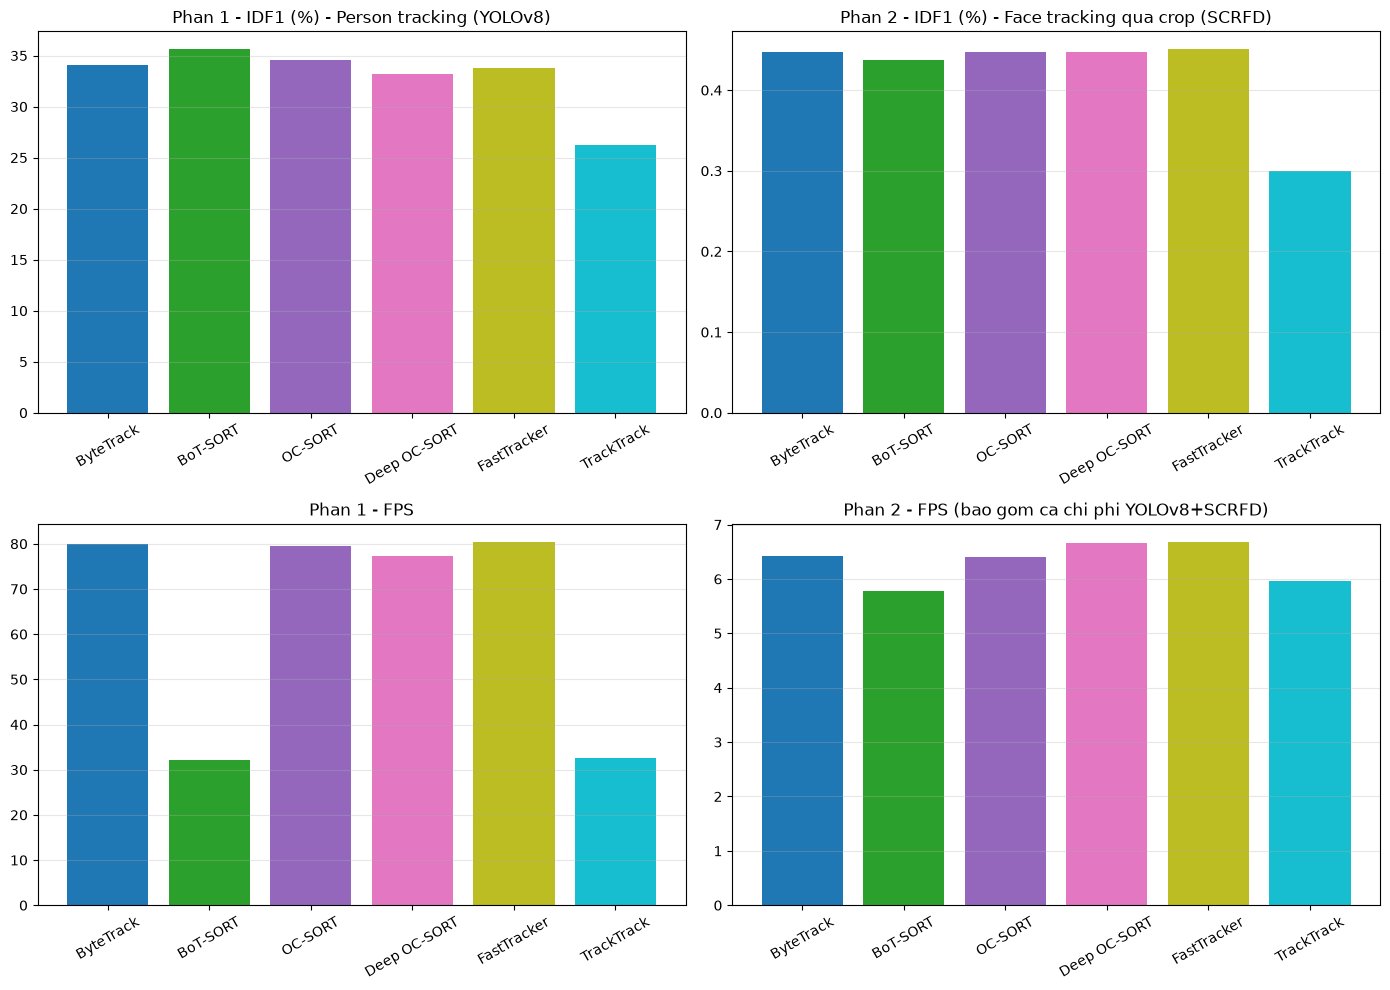

Da luu bieu do: D:\face-security-system\ai\models\tracker_results\tracking_comparison_2phan.png


In [13]:
# ===== CELL 13: Bieu do so sanh - dat 2 Phan canh nhau =====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.tab10(np.linspace(0, 1, 6))

if comparison_df_person is not None:
    trackers_p = comparison_df_person.index.tolist()
    axes[0, 0].bar(trackers_p, comparison_df_person['idf1'] * 100, color=colors[:len(trackers_p)])
    axes[0, 0].set_title('Phan 1 - IDF1 (%) - Person tracking (YOLOv8)')
    axes[0, 0].tick_params(axis='x', rotation=30)
    axes[0, 0].grid(axis='y', alpha=0.3)

    axes[1, 0].bar(trackers_p, comparison_df_person['fps'], color=colors[:len(trackers_p)])
    axes[1, 0].set_title('Phan 1 - FPS')
    axes[1, 0].tick_params(axis='x', rotation=30)
    axes[1, 0].grid(axis='y', alpha=0.3)

if comparison_df_face is not None:
    trackers_f = comparison_df_face.index.tolist()
    axes[0, 1].bar(trackers_f, comparison_df_face['idf1'] * 100, color=colors[:len(trackers_f)])
    axes[0, 1].set_title('Phan 2 - IDF1 (%) - Face tracking qua crop (SCRFD)')
    axes[0, 1].tick_params(axis='x', rotation=30)
    axes[0, 1].grid(axis='y', alpha=0.3)

    axes[1, 1].bar(trackers_f, comparison_df_face['fps'], color=colors[:len(trackers_f)])
    axes[1, 1].set_title('Phan 2 - FPS (bao gom ca chi phi YOLOv8+SCRFD)')
    axes[1, 1].tick_params(axis='x', rotation=30)
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'tracking_comparison_2phan.png')
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Da luu bieu do: {plot_path}")


## Ket luan

**Phan 1 (Person, ground truth that)** la can cu **dang tin cay nhat** de chon tracker
cho tang YOLOv8 trong `pipeline_runner.py` - dung truc tiep con so `>>> TOT NHAT
(Person) <<<` o Cell 12.

**Phan 2 (Face qua crop, ground truth xap xi)** chi nen dung de **so sanh TUONG DOI**
giua 6 tracker khi chung phai xu ly dau vao la mat (nho hon, xuat hien khong deu hon
nguoi) - KHONG dung so MOTA/IDF1 tuyet doi cua Phan 2 de bao cao nhu 1 con so chinh
xac, vi ground truth la uoc luong.

**FPS cua Phan 2 thap hon han Phan 1 la BINH THUONG, khong phai loi** - vi moi frame
phai chay CA YOLOv8 (tim nguoi) LAN SCRFD (tim mat tren tung crop, co the nhieu lan
neu nhieu nguoi trong khung hinh) roi moi den tracker - day chinh la FPS gan voi
thuc te cua `pipeline_runner.py` nhat trong tat ca cac notebook danh gia tu truoc
den gio.

Ghi lai tracker cuoi cung chon (dua chinh vao Phan 1) vao day:
`ByteTrack`